<a href="https://colab.research.google.com/github/Saifuddin-Yasir/ML-AI-Learning-Journey/blob/main/AI_ML_Assignment_3_Module_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [ ]:
# TODO: Import all necessary libraries here
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder,PolynomialFeatures, OrdinalEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error, r2_score,accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.svm import SVR,SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [ ]:
# TODO: Load regression dataset
from google.colab import files
data = files.upload()

Saving insurance.csv to insurance (2).csv


In [ ]:
data = pd.read_csv('insurance.csv')
print(f'Shape of the Dataset: {data.shape}')
print(f'Columns Names: {data.columns}')
target=data["charges"]

print('\n',target)

Shape of the Dataset: (1338, 7)
Columns Names: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

 0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Answer No A1**

At first, I upload the given dataset and load in. The dataset have 7 features and 1338 rows, Among those features, "charges" is the target features. Here, the shape and the column of the dataset displayed as instructed.

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


In [ ]:
# TODO: Perform EDA
print(data.describe().T)

           count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi          34.693750     53.13000  
children      2.000000      5.00000  
charges   16639.912515  63770.42801  


In [ ]:
lb= LabelEncoder()
data["sex"]=lb.fit_transform(data["sex"])
data['smoker']=lb.fit_transform(data['smoker'])
oh=OneHotEncoder(sparse_output=False,drop="first")
encoded  = oh.fit_transform(data[["region"]])
data_en = pd.DataFrame(encoded, columns=oh.get_feature_names_out(["region"]))
data = pd.concat([data, data_en], axis=1)
data.drop('region', axis=1, inplace=True)

ss = StandardScaler()
data["age"]=ss.fit_transform(data[["age"]])
data["bmi"]=ss.fit_transform(data[["bmi"]])

In [ ]:
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_eduction
0,-0.953538,0,4.0,0.100854,0,3.730699,1.683039,4.016394,3.0,-1.419814,...,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.525264
1,-1.118963,0,3.0,-1.127215,0,-0.967218,0.044782,-0.684829,2.0,-2.549975,...,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.849192
2,-0.457264,0,3.0,-1.124004,3,-0.345435,0.625557,3.443074,3.0,0.047412,...,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.849192
3,-0.788113,0,1.0,0.261499,0,3.730699,1.417829,3.443074,2.0,0.840507,...,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.502953
4,-0.622689,1,4.0,-0.018792,1,3.730699,1.095549,4.475050,4.0,-0.924130,...,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.525264


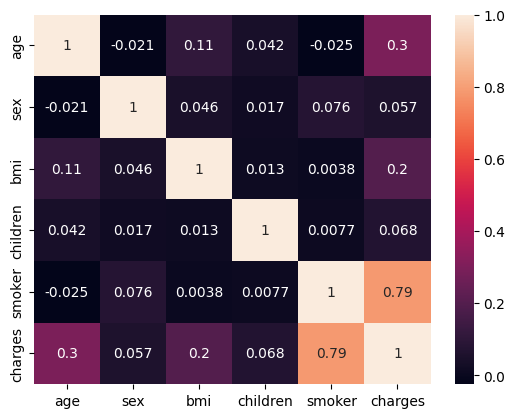

In [ ]:
datac = data.drop(columns=['region_northwest','region_southeast','region_southwest'])
corr_matrix = datac.corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

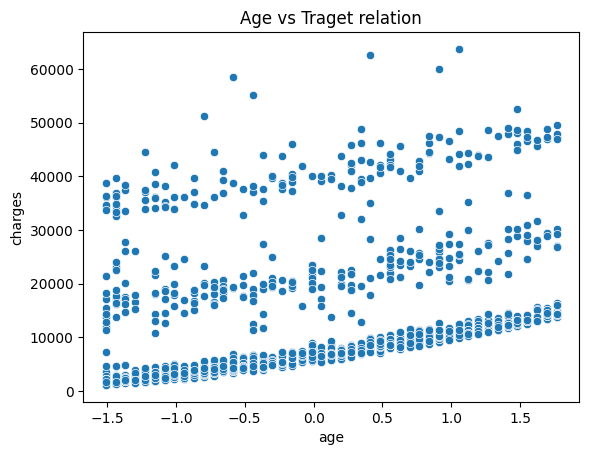

In [ ]:
sns.scatterplot(x='age', y='charges', data=data)
plt.title("Age vs Traget relation")
plt.show()

**Answer No A2**

The Overview of the given dataset is shown by describe function. from that, we can make decision for each particular features for preprocessing dataset for model usages. Then, also shown a relation with the target column. it's helps to show which features are important and correlate more. Here, smoker feature have highest 0.79 correlation with target. Age column have second highest correlation 0.3. lastly, I plotted a features "age" with target feature "charge".



## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [ ]:
# TODO: Prepare features
x = data.drop('charges', axis=1)
y = data['charges']
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.25,random_state=42)

**Answer No A3**

The dataset split by x, y. here, y is the 'charges' target column. then, the dataset splitted as train and test where we took test data 25% of total dataset.

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [ ]:
# TODO: Multiple Linear Regression
mlr = LinearRegression()
mlr.fit(x_train,y_train)
y_pred = mlr.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MAE: 4243.654116653145
RMSE: 5926.023602394469
R²: 0.7672642952734356


**Answer No A4**

Here, we choose linear Regression model and fit train dataset. Then, we predict for test data. Then, evaluate model efficiency by MAE, RMSE, R2. Here, we got 4243.65 MAE, it's means the model prediction are 4243.65 off by real. RMSE is 5926.03, that explains model are bad for especially outliers. and lstly, R2 is 0.76, the model is 76% accurate for variance data which is good enough.*italicized text*

## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [ ]:
# TODO: Polynomial Regression
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f"At linear Regression MAE: {mae} and polynomial Regression MAE: {mae_poly}")
print(f"At linear Regression RMSE: {rmse} and polynomial Regression RMSE: {rmse_poly}")
print(f"At linear Regression R²: {r2} and polynomial Regression R²: {r2_poly}")

At linear Regression MAE: 4243.654116653145 and polynomial Regression MAE: 2781.7101811018597
At linear Regression RMSE: 5926.023602394469 and polynomial Regression RMSE: 4689.452858277405
At linear Regression R²: 0.7672642952734356 and polynomial Regression R²: 0.854259380947993


**Answer No A5**

For polynomial regression ,there is a need of polynomial data. First, it make implement on features data(x). the data fitted to linear regression as done before then, evaluate model by MAE, RMSE, R2. lastly, printed the result for both polynomial and linear regression as for comparison. in comparision,we got polynomial regression model done good result than linear regression.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [ ]:
# TODO: Support Vector Regression
svr= SVR(kernel="rbf",C=10000)
svr.fit(x_train,y_train)
y_pred_svr = svr.predict(x_test)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR MAE: {mae_svr}")
print(f"SVR RMSE: {rmse_svr}")
print(f"SVR R²: {r2_svr}")

SVR MAE: 1892.021576643634
SVR RMSE: 5001.274369796857
SVR R²: 0.834233173856594


**Answer No A6**

Here, we choose support vector regressor as our model. Fit data to our model then predict for test data. Then, We, evaluate as usual by MAE, RMSE, R2. Here, as parameter used in model svr, C is 10000 And make gamma as auto.Here, we choose rbf as kernel, because it can handle most of dataset very well. It make model robust. For non-linear data,it works well and we can use it without thinking. Polynomial also work well but it need to set perfect C and gamma.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)

In [ ]:
# TODO: Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=450, random_state=42)
rfr.fit(x_train, y_train)
y_pred_rfr = rfr.predict(x_test)
mae_rfr = mean_absolute_error(y_test, y_pred_rfr)
rmse_rfr = np.sqrt(mean_squared_error(y_test, y_pred_rfr))
r2_rfr = r2_score(y_test, y_pred_rfr)

print(f"RFR MAE: {mae_rfr}")
print(f"RFR RMSE: {rmse_rfr}")
print(f"RFR R²: {r2_rfr}")

RFR MAE: 2601.261205336264
RFR RMSE: 4744.958076094273
RFR R²: 0.8507889383831649


**Answer No A7**

Here, we choose random forest regressor as our model. Fit data to our model then predict for test data. Then, We, evaluate as usual by MAE, RMSE, R2. Here, as parameter used in model svr,n_estimators is 300 And make other parameter as auto.

In [ ]:
print(f"At linear Regression R²: {r2} and polynomial Regression R²: {r2_poly}")
print(f"SVR R²: {r2_svr}")
print(f"RFR R²: {r2_rfr}")

At linear Regression R²: 0.7672642952734356 and polynomial Regression R²: 0.854259380947993
SVR R²: 0.834233173856594
RFR R²: 0.8507889383831649


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.

## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [ ]:
# TODO: Load classification dataset
data = files.upload()

data = pd.read_csv('loan_data (2).csv')

class_count= data['loan_status'].value_counts()
print(class_count)

Saving loan_data.csv to loan_data (3).csv
loan_status
0    35000
1    10000
Name: count, dtype: int64


**Answer No B1**

Here,the choosen dataset loaded. The dataset set have huge class imbalance. For loan Status '0',it have around 35000 data. Other side, for '1' loan status it have only 10000. Which make model more bias on loan status '0'.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


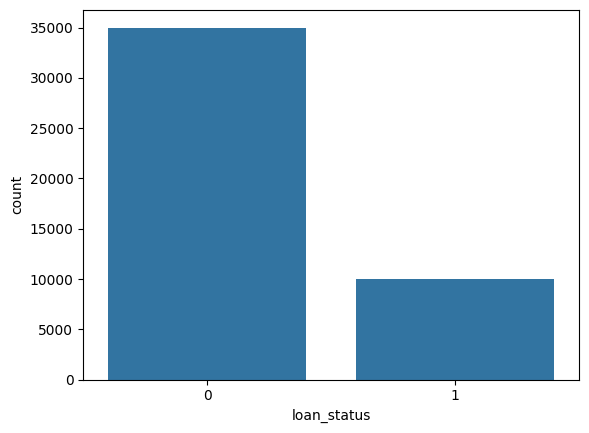

In [ ]:
# TODO: Classification EDA
data = pd.read_csv('loan_data.csv')
sns.countplot(data=data,x=data['loan_status'])
plt.show()

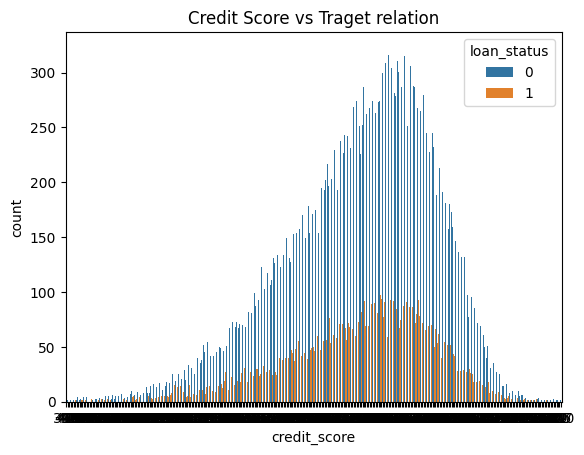

In [ ]:
sns.countplot(x='credit_score', hue='loan_status' , data=data)
plt.title("Credit Score vs Traget relation")
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [ ]:
# TODO: Prepare classification features
lb=LabelEncoder()
oe =OrdinalEncoder()
ohe=OneHotEncoder(sparse_output=False, drop="first")

data['person_gender']= lb.fit_transform(data['person_gender'])
data['previous_loan_defaults_on_file']= lb.fit_transform(data['previous_loan_defaults_on_file'])
data['person_education']= oe.fit_transform(data[['person_education']])
ohe_cols = ['person_home_ownership', 'loan_intent']
encoded_features = ohe.fit_transform(data[ohe_cols])
encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(ohe_cols))

data = pd.concat([data.drop(columns=ohe_cols), encoded_df], axis=1)
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,4.0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21.0,0,3.0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25.0,0,3.0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,23.0,0,1.0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,24.0,1,4.0,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
ss= StandardScaler()
rs= RobustScaler()
data['person_income']=rs.fit_transform(data[['person_income']])
data['loan_amnt']=rs.fit_transform(data[['loan_amnt']])
data['person_age']=ss.fit_transform(data[['person_age']])
data['person_eduction']=ss.fit_transform(data[['person_education']])
data['loan_int_rate']=ss.fit_transform(data[['loan_int_rate']])
data['loan_percent_income']=ss.fit_transform(data[['loan_percent_income']])
data['credit_score']=ss.fit_transform(data[['credit_score']])

data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_eduction
0,-0.953538,0,4.0,0.100854,0,3.730699,1.683039,4.016394,3.0,-1.419814,...,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.525264
1,-1.118963,0,3.0,-1.127215,0,-0.967218,0.044782,-0.684829,2.0,-2.549975,...,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.849192
2,-0.457264,0,3.0,-1.124004,3,-0.345435,0.625557,3.443074,3.0,0.047412,...,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.849192
3,-0.788113,0,1.0,0.261499,0,3.730699,1.417829,3.443074,2.0,0.840507,...,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.502953
4,-0.622689,1,4.0,-0.018792,1,3.730699,1.095549,4.475050,4.0,-0.924130,...,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.525264


In [ ]:
x=data.drop('loan_status',axis=1)
y=data['loan_status']
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [ ]:
# TODO: Logistic Regression
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

accuracy= accuracy_score(y_test,y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cmatrix = confusion_matrix(y_test,y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(cmatrix)

Accuracy: 0.8994444444444445
Precision: 0.7889182058047494
Recall: 0.7475
[[6600  400]
 [ 505 1495]]


## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [ ]:
# TODO: SVM Classification
svm = SVC(kernel="linear")
svm.fit(x_train,y_train)
y_pred_svm = svm.predict(x_test)
cmatrix = confusion_matrix(y_test,y_pred_svm)

accuracy_svml= accuracy_score(y_test, y_pred_svm)
precision_svml = precision_score(y_test, y_pred_svm)
recall_svml = recall_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svml}")
print(f"Precision: {precision_svml}")
print(f"Recall: {recall_svml}")
print(cmatrix)

Accuracy: 0.8996666666666666
Precision: 0.7925333333333333
Recall: 0.743
[[6611  389]
 [ 514 1486]]


In [ ]:
svm = SVC(kernel="rbf")
svm.fit(x_train,y_train)
y_pred_svm = svm.predict(x_test)
cmatrix = confusion_matrix(y_test,y_pred_svm)

accuracy_svmr = accuracy_score(y_test, y_pred_svm)
precision_svmr = precision_score(y_test, y_pred_svm)
recall_svmr= recall_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svmr}")
print(f"Precision: {precision_svmr}")
print(f"Recall: {recall_svmr}")
print(cmatrix)

Accuracy: 0.9078888888888889
Precision: 0.8236594803758983
Recall: 0.745
[[6681  319]
 [ 510 1490]]


## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [ ]:
# TODO: Naive Bayes
gnb= GaussianNB()
gnb.fit(x_train,y_train)
y_pred_gnb = gnb.predict(x_test)
cmatrix = confusion_matrix(y_test,y_pred_gnb)

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
print(f"Accuracy: {accuracy_gnb}")
print(f"Precision: {precision_gnb}")
print(f"Recall: {recall_gnb}")
print(cmatrix)

Accuracy: 0.7548888888888889
Precision: 0.4750363548230732
Recall: 0.98
[[4834 2166]
 [  40 1960]]


## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


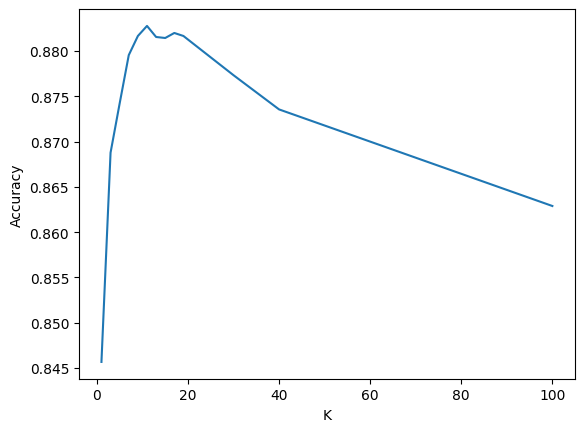

In [ ]:
# TODO: KNN
k=[1,3,5,7,9,11,13,15,17,19,30,40,100]
acc=[]
for i in k:
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  y_pred_knn = knn.predict(x_test)
  accuracy_knn = accuracy_score(y_test, y_pred_knn)
  acc.append(accuracy_knn)

plt.plot(k,acc)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
best_k = k[acc.index(max(acc))]
print(f"Best K:{best_k}")
print(f"Best Accuracy:{max(acc)}")

Best K:11
Best Accuracy:0.8827777777777778


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [ ]:
# TODO: Random Forest Classifier
rf = RandomForestClassifier(n_estimators=300,max_depth=4,random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
cmatrix = confusion_matrix(y_test,y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf= recall_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf}")
print(f"Precision: {precision_rf}")
print(f"Recall: {recall_rf}")
print(cmatrix)

feature_importances =pd.Series(rf.feature_importances_,index=x.columns).sort_values(ascending=False)
print("\n",feature_importances)

Accuracy: 0.8915555555555555
Precision: 0.9483362521891419
Recall: 0.5415
[[6941   59]
 [ 917 1083]]

 previous_loan_defaults_on_file    0.397070
loan_percent_income               0.220724
loan_int_rate                     0.145179
person_income                     0.099233
person_home_ownership_RENT        0.081353
loan_amnt                         0.026354
person_home_ownership_OWN         0.010612
loan_intent_VENTURE               0.005422
credit_score                      0.003916
loan_intent_MEDICAL               0.003551
loan_intent_EDUCATION             0.002425
loan_intent_HOMEIMPROVEMENT       0.002401
person_age                        0.000551
person_emp_exp                    0.000427
cb_person_cred_hist_length        0.000284
loan_intent_PERSONAL              0.000251
person_home_ownership_OTHER       0.000147
person_eduction                   0.000058
person_education                  0.000027
person_gender                     0.000014
dtype: float64


In [ ]:
print(f"Accuracy for LR: {accuracy}")
print(f"Accuracy for SVR(linear): {accuracy_svml}")
print(f"Accuracy for SVR(RBF): {accuracy_svmr}")
print(f"Accuracy for Gassian NB: {accuracy_gnb}")
print(f"Accuracy for KNN:{max(acc)}")
print(f"Accuracy for Random forest Classifier: {accuracy_rf}")

Accuracy for LR: 0.8994444444444445
Accuracy for SVR(linear): 0.8996666666666666
Accuracy for SVR(RBF): 0.9078888888888889
Accuracy for Gassian NB: 0.7548888888888889
Accuracy for KNN:0.8827777777777778
Accuracy for Random forest Classifier: 0.8915555555555555


# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario




## TODO: Write your reflection here


1.  Best regression model polynomial regression. its r2 value is 0.85. similarly,Random forest regressor have 0.85 r2 value.so, we can say both are best model according to dataset.This indicates that these models are able to explain approximately 85% of the variance in the target variable. Polynomial Regression performs well because it can capture the non-linear relationship between input features and the output, which simple linear regression fails to model effectively. On the other hand, the Random Forest Regressor benefits from ensemble learning, making it robust to outliers,also it's capable of handling complex interactions among features. Since both models achieved equal performance, they are considered the most suitable regression models for this dataset.

2.  Best classification model is SVC for Rbf kernal .it's accuracy is 0.90. random forest classifier and SVR for linear kernal are also best enough .there's accuracy is 0.89. The RBF kernel enables the classifier to learn non-linear decision boundaries which make it better generalization on unseen data.Other models such as the Random Forest Classifier and SVC with linear kernel also performed competitively with accuracies of 0.89, but the RBF-based SVC slightly outperformed them, making it the preferred classification model for used dataset.

3. in a real-world deployment scenario,these models can be applied in a financial risk assessment system. The regression models can be used to predict loan amounts or expected financial charges, while the classification model can determine whether an applicant is likely to default, thereby supporting accurate, automated decision-making in banking and insurance sectors.




